In [11]:
import matplotlib.pylab as plt
import numpy as np

In [12]:
NUM_TRIALS=10000
EPS=0.1
BANDIT_PROBABILITIES=[.2,.5,.75]

In [13]:
class Bandit:
    def __init__(self,p):
        self.p=p
        self.p_estimate=0
        self.N=0
        
    def pull(self):
        return np.random.random()<self.p
    
    def update(self,x):
        self.N=self.N+1
        self.p_estimate=((self.p_estimate*(self.N-1))+x)/self.N
    

In [14]:
def expriment():
    bandits = [Bandit(p) for p in BANDIT_PROBABILITIES]
    rewards=np.zeros(NUM_TRIALS)
    num_times_explored=0
    num_tims_exploided=0
    num_optimal=0
    optimal_j=np.argmax([b.p for b in bandits])
    print("optimal j",optimal_j)
    for i in range (NUM_TRIALS):
        if np.random.random() <EPS:
            num_times_explored +=1
            j= np.random.randint(len(bandits))
        else:
            num_tims_exploided +=1
            j=np.argmax([b.p_estimate for b in bandits])
        if j==optimal_j:
            num_optimal +=1
        
        x=bandits[j].pull()
        rewards[i]=x
        bandits[j].update(x)
    
    for b in bandits:
        print("mean estimate:",b.p_estimate)
    
    print("total reward earned:",rewards.sum())
    print("overall win rate:",rewards.sum()/NUM_TRIALS)
    print("num_times_explord:",num_times_explored)
    print("num_times_exploided:",num_tims_exploided)        
    print("num times selected optimal bandit:",num_optimal)
        
    cumulative_rewards=np.cumsum(rewards)
    win_rates=cumulative_rewards/(np.arange(NUM_TRIALS)+1)
    
    plt.plot(win_rates)
    plt.plot(np.ones(NUM_TRIALS)*np.max(BANDIT_PROBABILITIES))
    plt.show()

optimal j 2
mean estimate: 0.19714285714285715
mean estimate: 0.49162011173184356
mean estimate: 0.7515066724063693
total reward earned: 7228.0
overall win rate: 0.7228
num_times_explord: 1051
num_times_exploided: 8949
num times selected optimal bandit: 9292


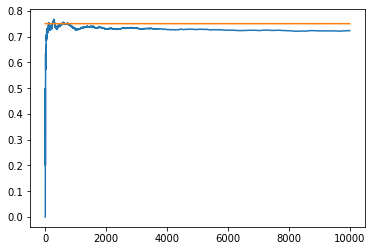

In [15]:
if __name__ =="__main__":
    expriment()